# Rocket Launch EDA for NOAA Weather Join Planning

This notebook profiles the launch data in `data/` with one practical goal:
identify the date coverage and U.S. ZIP-code coverage needed to pull NOAA weather
data for a launch-weather modeling project.

The analysis focuses on:
- launch date coverage
- location normalization for U.S. launch sites
- candidate ZIP codes for NOAA extraction
- data quality issues that matter before weather joins


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from geopy.extra.rate_limiter import RateLimiter
from geopy.geocoders import Nominatim

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="deep")

DATA_DIR = Path("data")
OUTPUT_DIR = DATA_DIR / "derived"
OUTPUT_DIR.mkdir(exist_ok=True)

WEATHER_NUMERIC_COLUMNS = [
    "HourlyAltimeterSetting",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyStationPressure",
    "HourlySeaLevelPressure",
    "HourlyWetBulbTemperature",
    "HourlyWindSpeed",
    "HourlyWindGustSpeed",
    "HourlyWindDirection",
]
WEATHER_TEXT_COLUMNS = ["HourlyPresentWeatherType", "HourlySkyConditions"]
SHORT_DURATION_PRECIP_COLUMNS = [
    "ShortDurationPrecipitationValue005",
    "ShortDurationPrecipitationValue010",
    "ShortDurationPrecipitationValue015",
    "ShortDurationPrecipitationValue020",
    "ShortDurationPrecipitationValue030",
    "ShortDurationPrecipitationValue045",
    "ShortDurationPrecipitationValue060",
    "ShortDurationPrecipitationValue080",
    "ShortDurationPrecipitationValue100",
    "ShortDurationPrecipitationValue120",
    "ShortDurationPrecipitationValue150",
    "ShortDurationPrecipitationValue180",
]
WEATHER_FILE_MAP = {
    "Cape Canaveral Space Force Station": ("cape_canaveral_sfs/cape_canaveral_sfs.csv", -5),
    "Kennedy Space Center": ("kennedy_sc/kennedy_sc.csv", -5),
    "Vandenberg Space Force Base": ("vandenberg_sfb/vandenberg_sfb.csv", -8),
    "Wallops Flight Facility": ("wallops_flight_facility/wallops_flight_facility.csv", -5),
    "Pacific Spaceport Complex Alaska": ("pacific_spaceport_alaska/pacific_spaceport_alaska.csv", -9),
    "Pacific Missile Range Facility": ("pacific_missile_range/pacific_missile_range.csv", -10),
    "Mojave Air and Space Port": ("mojave_air_space_port/mojave_air_space_port.csv", -8),
    "Edwards Air Force Base": ("edwards_afb/edwards_afb.csv", -8),
    "China Lake": ("china_lake/china_lake.csv", -8),
}


In [2]:
companies = pd.read_csv(DATA_DIR / "Companies.csv")
configs = pd.read_csv(DATA_DIR / "Configs.csv")
families = pd.read_csv(DATA_DIR / "Families.csv")
launches = pd.read_csv(DATA_DIR / "Launches.csv")
locations = pd.read_csv(DATA_DIR / "Locations.csv")
missions = pd.read_csv(DATA_DIR / "Missions.csv")

dataset_shapes = pd.DataFrame(
    {
        "dataset": [
            "Companies",
            "Configs",
            "Families",
            "Launches",
            "Locations",
            "Missions",
        ],
        "rows": [
            len(companies),
            len(configs),
            len(families),
            len(launches),
            len(locations),
            len(missions),
        ],
        "columns": [
            companies.shape[1],
            configs.shape[1],
            families.shape[1],
            launches.shape[1],
            locations.shape[1],
            missions.shape[1],
        ],
    }
)

dataset_shapes


,dataset,rows,columns
0,Companies,59,3
1,Configs,480,13
2,Families,205,8
3,Launches,6168,16
4,Locations,145,14
5,Missions,7450,4


## Global Launch Site Footprint

Before narrowing to the current U.S.-focused NOAA workflow, it is useful to understand
the full launch-site footprint in the raw dataset. This section looks across **all**
launches and all joined launch sites so you can evaluate how realistic it would be to
expand the project to non-U.S. weather sources.

The main questions are:
- which countries account for the most launches
- which combined launch sites dominate the data volume
- whether the raw dataset already contains usable coordinates for those sites
- which non-U.S. sites would be the highest-priority targets for future weather sourcing


In [3]:
global_launch_scope = launches.merge(
    locations[
        [
            "Orig_Addr",
            "Country",
            "Country_Code",
            "Launch Site",
            "Comb Launch Site",
            "Lat",
            "Lon",
            "Comb Launch Site Lat",
            "Comb Launch Site Lon",
        ]
    ],
    left_on="Location",
    right_on="Orig_Addr",
    how="left",
).copy()

global_launch_scope["Country_Code"] = global_launch_scope["Country_Code"].astype(str).str.upper()
global_launch_scope["country_joined"] = global_launch_scope["Country"].notna()
global_launch_scope["combined_site_joined"] = global_launch_scope["Comb Launch Site"].notna()

scope_join_summary = pd.DataFrame(
    {
        "metric": [
            "total launches",
            "unique raw location strings",
            "launches with country joined",
            "launches with combined site joined",
            "unique countries in joined scope",
            "unique combined launch sites in joined scope",
        ],
        "value": [
            len(global_launch_scope),
            global_launch_scope["Location"].nunique(),
            int(global_launch_scope["country_joined"].sum()),
            int(global_launch_scope["combined_site_joined"].sum()),
            int(global_launch_scope["Country"].nunique()),
            int(global_launch_scope["Comb Launch Site"].nunique()),
        ],
    }
)

scope_join_summary


,metric,value
0,total launches,6168
1,unique raw location strings,137
2,launches with country joined,6166
3,launches with combined site joined,6168
4,unique countries in joined scope,19
5,unique combined launch sites in joined scope,39


This quick audit shows whether the raw launch records can already be mapped to countries
and combined sites. If most launches join cleanly, then extending the project beyond the
U.S. is mainly a **weather-source acquisition** problem rather than a launch-site
normalization problem.


In [4]:
country_scope_summary = (
    global_launch_scope.groupby(["Country", "Country_Code"], dropna=False)
    .agg(
        launches=("Launch Id", "count"),
        unique_raw_locations=("Location", "nunique"),
        unique_combined_sites=("Comb Launch Site", "nunique"),
    )
    .reset_index()
    .sort_values(["launches", "unique_combined_sites"], ascending=[False, False])
)

country_scope_summary.head(20)


,Country,Country_Code,launches,unique_raw_locations,unique_combined_sites
18,United States,US,1784,50,8
15,Russia,RU,1774,20,6
9,Kazakhstan,KZ,1525,21,1
3,China,CN,439,15,4
4,French Guiana,GF,311,6,1
8,Japan,JP,127,4,2
5,India,IN,78,3,1
11,Kiribati,KI,36,1,1
13,New Zealand,NZ,23,2,1
6,Iran,IR,14,2,2


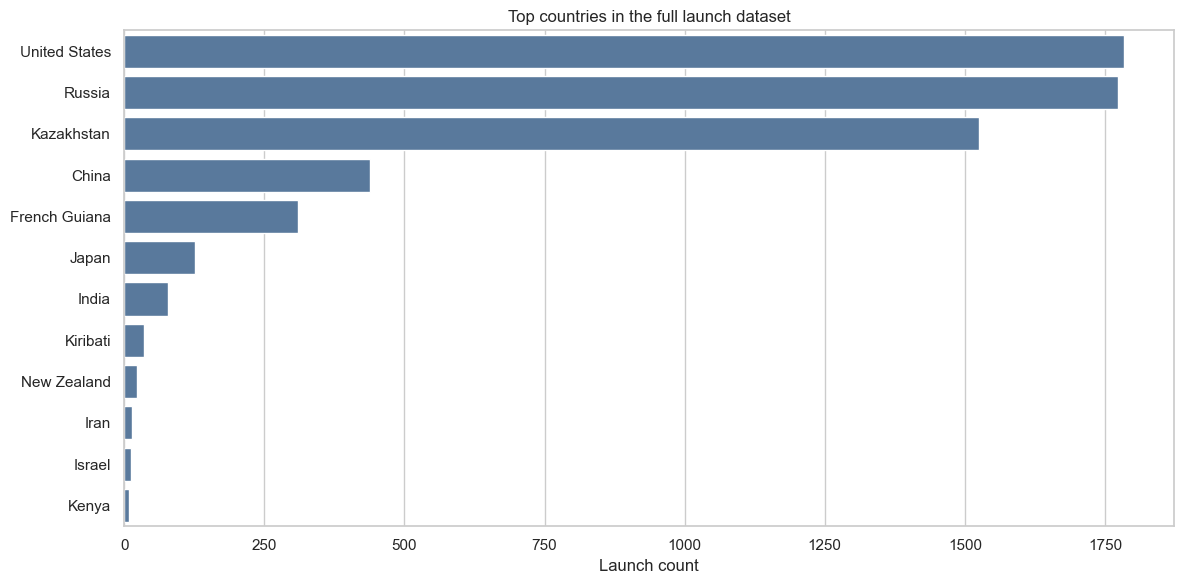

In [5]:
plt.figure(figsize=(12, 6))
top_countries = country_scope_summary.head(12).copy()
sns.barplot(data=top_countries, y="Country", x="launches", color="#4e79a7")
plt.title("Top countries in the full launch dataset")
plt.xlabel("Launch count")
plt.ylabel("")
plt.tight_layout()
plt.show()


This table and chart help define the practical expansion path. If the goal is to broaden
weather coverage, the highest-leverage countries are the ones with both substantial launch
counts and repeated site usage, because those are the locations where a weather-data
investment would affect the most rows.


In [6]:
site_scope_summary = (
    global_launch_scope.groupby(
        [
            "Country",
            "Country_Code",
            "Comb Launch Site",
            "Comb Launch Site Lat",
            "Comb Launch Site Lon",
        ],
        dropna=False,
    )
    .agg(
        launches=("Launch Id", "count"),
        unique_raw_locations=("Location", "nunique"),
    )
    .reset_index()
    .sort_values(["launches", "Country", "Comb Launch Site"], ascending=[False, True, True])
)

site_scope_summary.head(25)


,Country,Country_Code,Comb Launch Site,Comb Launch Site Lat,Comb Launch Site Lon,launches,unique_raw_locations
22,Russia,RU,Plesetsk Cosmodrome,62.926415,40.555239,1648,11
14,Kazakhstan,KZ,Baikonur Cosmodrome,45.964585,63.305243,1525,21
29,United States,US,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792,1002,24
35,United States,US,Vandenberg SFB,34.698327,-120.585452,711,16
7,French Guiana,GF,Guiana SC,5.201590,-52.728131,311,6
6,China,CN,Xichang Satellite LC,27.893551,102.250931,167,3
3,China,CN,Jiuquan Satellite LC,40.984524,100.208695,158,6
4,China,CN,Taiyuan Satellite LC,38.848577,111.607983,99,4
21,Russia,RU,Kapustin Yar,48.575267,45.766175,97,3
12,Japan,JP,Tanegashima SC,30.374865,130.957646,85,2


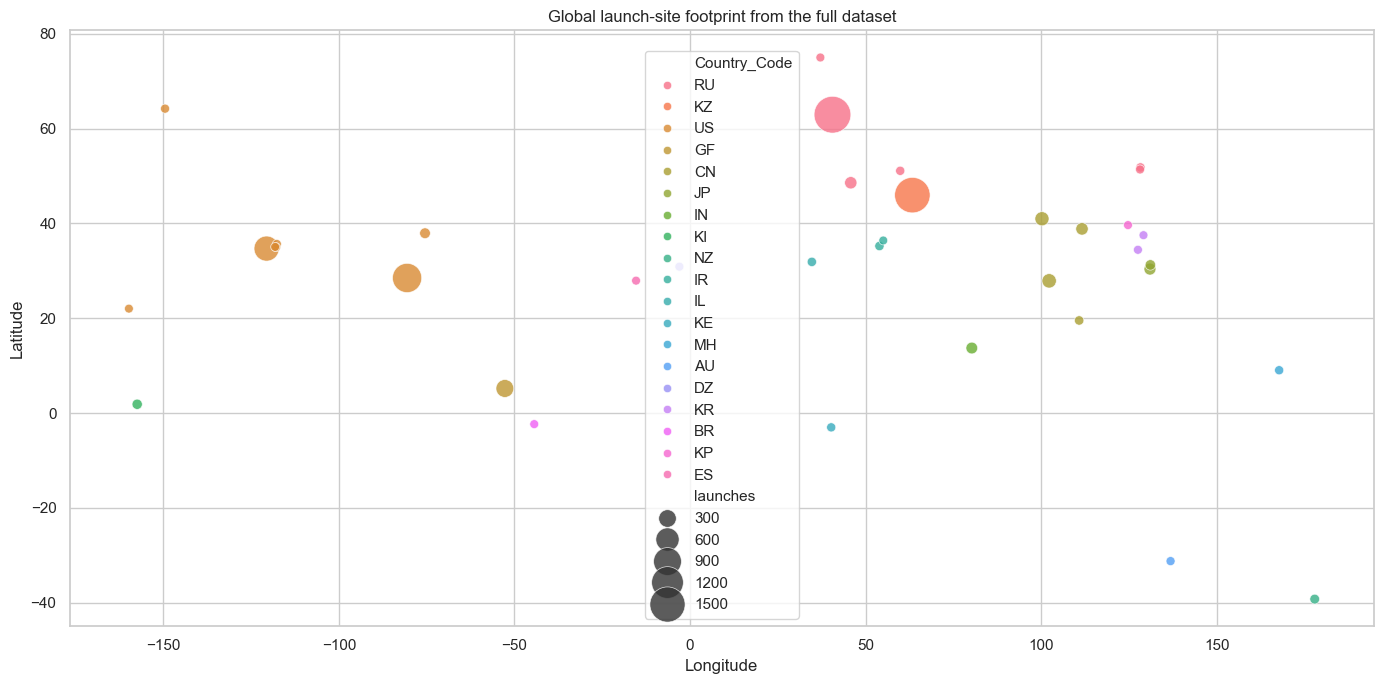

In [7]:
mapped_sites = site_scope_summary.dropna(subset=["Comb Launch Site Lat", "Comb Launch Site Lon"]).copy()
mapped_sites["site_label"] = mapped_sites["Comb Launch Site"] + " (" + mapped_sites["Country_Code"] + ")"

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=mapped_sites,
    x="Comb Launch Site Lon",
    y="Comb Launch Site Lat",
    size="launches",
    hue="Country_Code",
    sizes=(40, 700),
    alpha=0.8,
    legend="brief",
)
plt.title("Global launch-site footprint from the full dataset")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


The latitude/longitude plot is not a political map, but it is enough for planning
purposes. It shows where the major launch clusters sit geographically and whether the
dataset already has site-level coordinates that could support future weather joins from
non-NOAA sources.


In [8]:
non_us_site_scope = (
    site_scope_summary[site_scope_summary["Country_Code"] != "US"]
    .copy()
    .reset_index(drop=True)
)

non_us_site_scope.head(25)


,Country,Country_Code,Comb Launch Site,Comb Launch Site Lat,Comb Launch Site Lon,launches,unique_raw_locations
0,Russia,RU,Plesetsk Cosmodrome,62.926415,40.555239,1648,11
1,Kazakhstan,KZ,Baikonur Cosmodrome,45.964585,63.305243,1525,21
2,French Guiana,GF,Guiana SC,5.201590,-52.728131,311,6
3,China,CN,Xichang Satellite LC,27.893551,102.250931,167,3
4,China,CN,Jiuquan Satellite LC,40.984524,100.208695,158,6
5,China,CN,Taiyuan Satellite LC,38.848577,111.607983,99,4
6,Russia,RU,Kapustin Yar,48.575267,45.766175,97,3
7,Japan,JP,Tanegashima SC,30.374865,130.957646,85,2
8,India,IN,Satish Dhawan SC,13.728419,80.229276,78,3
9,Japan,JP,Uchinoura SC,31.251267,131.076127,42,2


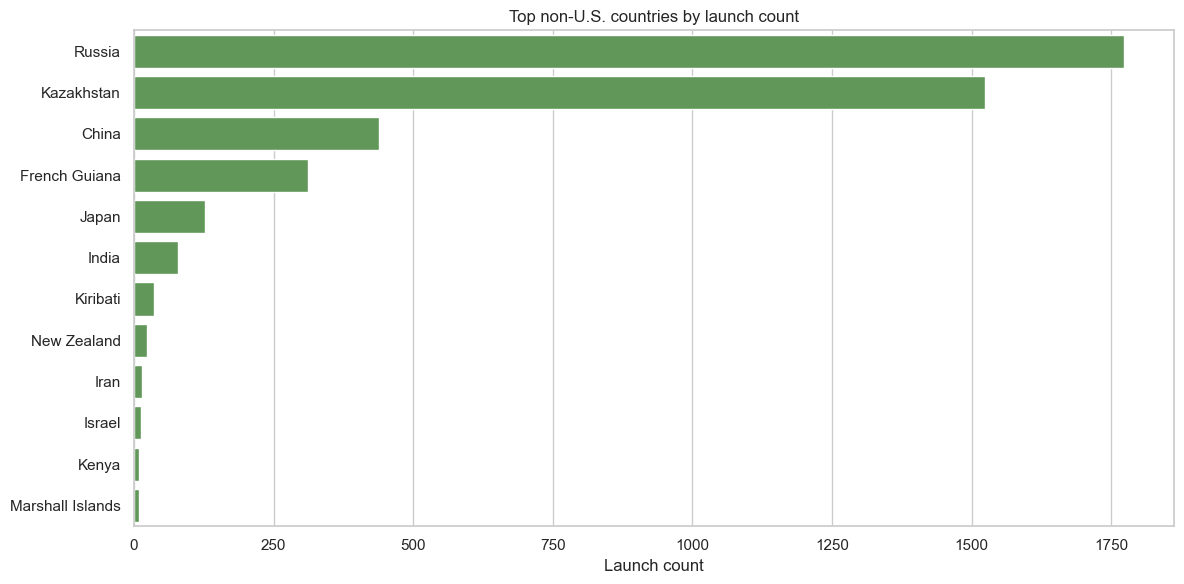

In [9]:
non_us_country_scope = (
    country_scope_summary[country_scope_summary["Country_Code"] != "US"]
    .copy()
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=non_us_country_scope.head(12), y="Country", x="launches", color="#59a14f")
plt.title("Top non-U.S. countries by launch count")
plt.xlabel("Launch count")
plt.ylabel("")
plt.tight_layout()
plt.show()


This non-U.S. summary is the most directly useful table for the project-expansion question.
It identifies the countries and combined launch sites that would matter most if you decide
to research international weather data sources. In practice, the likely first targets are
the biggest repeated non-U.S. sites, such as major launch complexes in Russia,
Kazakhstan, French Guiana, China, Japan, and India.


## Launch-Level Preparation

`Launches.csv` is the core table for weather joins. We convert timestamps, join site
metadata from `Locations.csv`, and derive a few fields that make the NOAA prep work
easier.


In [10]:
def parse_numeric_text(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.extract(r"([-+]?[0-9]*\.?[0-9]+)")[0],
        errors="coerce",
    )


launch_df = launches.copy()
launch_df["launch_time_utc"] = pd.to_datetime(launch_df["Launch Time"], utc=True, errors="coerce")
launch_df["launch_date"] = launch_df["launch_time_utc"].dt.date
launch_df["launch_year"] = launch_df["launch_time_utc"].dt.year
launch_df["launch_month"] = launch_df["launch_time_utc"].dt.month
launch_df["launch_month_name"] = launch_df["launch_time_utc"].dt.month_name()
launch_df["launch_decade"] = (launch_df["launch_year"] // 10) * 10

mission_agg = (
    missions.groupby("Launch Id")
    .agg(
        payload_count=("Payloads", "sum"),
        mission_mass=("Mass", "sum"),
        mission_rows=("No", "count"),
    )
    .reset_index()
)

config_features = configs.merge(
    families[["Family Id", "Family", "Success Rate"]],
    on="Family Id",
    how="left",
).copy()

for col in [
    "Liftoff Thrust",
    "Payload to LEO",
    "Payload to GTO",
    "Stages",
    "Strap-ons",
    "Rocket Height",
    "Fairing Diameter",
    "Fairing Height",
]:
    if col in config_features.columns:
        config_features[col] = parse_numeric_text(config_features[col])

config_features["family_success_rate_pct"] = (
    config_features["Success Rate"].astype(str).str.rstrip("%")
)
config_features["family_success_rate_pct"] = pd.to_numeric(
    config_features["family_success_rate_pct"],
    errors="coerce",
)

launch_df = launch_df.merge(
    locations[
        [
            "Orig_Addr",
            "Country",
            "Country_Code",
            "Operator",
            "Launch Site",
            "Comb Launch Site",
            "Lat",
            "Lon",
            "Comb Launch Site Lat",
            "Comb Launch Site Lon",
        ]
    ],
    left_on="Location",
    right_on="Orig_Addr",
    how="left",
)
launch_df = launch_df.merge(mission_agg, on="Launch Id", how="left")
launch_df = launch_df.merge(
    config_features[
        [
            "Config",
            "Status",
            "Liftoff Thrust",
            "Payload to LEO",
            "Payload to GTO",
            "Stages",
            "Strap-ons",
            "Rocket Height",
            "Fairing Diameter",
            "Fairing Height",
            "Family",
            "family_success_rate_pct",
        ]
    ],
    left_on="Rocket Name",
    right_on="Config",
    how="left",
)

launch_df["location_joined"] = launch_df["Orig_Addr"].notna()
launch_df = launch_df.rename(
    columns={
        "Payload to LEO": "config_payload_leo",
        "Payload to GTO": "config_payload_gto",
        "Status": "config_status",
        "Liftoff Thrust": "config_liftoff_thrust",
        "Stages": "config_stages",
        "Strap-ons": "config_strap_ons",
        "Rocket Height": "config_rocket_height",
        "Fairing Diameter": "config_fairing_diameter",
        "Fairing Height": "config_fairing_height",
        "Family": "rocket_family",
    }
)

prep_summary = pd.DataFrame(
    {
        "metric": [
            "total launches",
            "missing launch timestamps",
            "missing locations",
            "location joins missing",
            "unique raw locations",
            "unique combined launch sites",
            "mission aggregates available",
            "config family available",
        ],
        "value": [
            len(launch_df),
            int(launch_df["launch_time_utc"].isna().sum()),
            int(launch_df["Location"].isna().sum()),
            int((~launch_df["location_joined"]).sum()),
            int(launch_df["Location"].nunique()),
            int(launch_df["Comb Launch Site"].nunique()),
            int(launch_df["payload_count"].notna().sum()),
            int(launch_df["rocket_family"].notna().sum()),
        ],
    }
)

prep_summary


,metric,value
0,total launches,6168
1,missing launch timestamps,0
2,missing locations,0
3,location joins missing,0
4,unique raw locations,137
5,unique combined launch sites,39
6,mission aggregates available,5557
7,config family available,6168


## U.S. Scope for NOAA

This notebook is intentionally limited to **U.S. launches** because the next step is to
join launches to NOAA weather data using **launch date + ZIP code**. The raw launch data
does not include ZIP codes, and that join strategy is only directly applicable to U.S.
launch sites.


In [11]:
us_launches = launch_df[launch_df["Country_Code"] == "US"].copy()

us_summary = pd.DataFrame(
    {
        "metric": [
            "U.S. launches",
            "U.S. min launch date",
            "U.S. max launch date",
            "unique U.S. raw location strings",
            "unique U.S. combined launch sites",
        ],
        "value": [
            len(us_launches),
            str(us_launches["launch_date"].min()),
            str(us_launches["launch_date"].max()),
            int(us_launches["Location"].nunique()),
            int(us_launches["Comb Launch Site"].nunique()),
        ],
    }
)

us_summary


,metric,value
0,U.S. launches,1784
1,U.S. min launch date,1957-12-06
2,U.S. max launch date,2021-12-21
3,unique U.S. raw location strings,50
4,unique U.S. combined launch sites,8


In [12]:
us_status_counts = (
    us_launches["Launch Status"]
    .value_counts()
    .rename_axis("launch_status")
    .reset_index(name="launches")
)

us_status_counts


,launch_status,launches
0,Success,1597
1,Failure,153
2,Partial Failure,33
3,Prelaunch Failure,1


In [13]:
us_by_decade = (
    us_launches.groupby("launch_decade")
    .size()
    .rename("launches")
    .reset_index()
    .sort_values("launch_decade")
)

us_by_decade


,launch_decade,launches
0,1950,43
1,1960,535
2,1970,273
3,1980,161
4,1990,293
5,2000,186
6,2010,211
7,2020,82


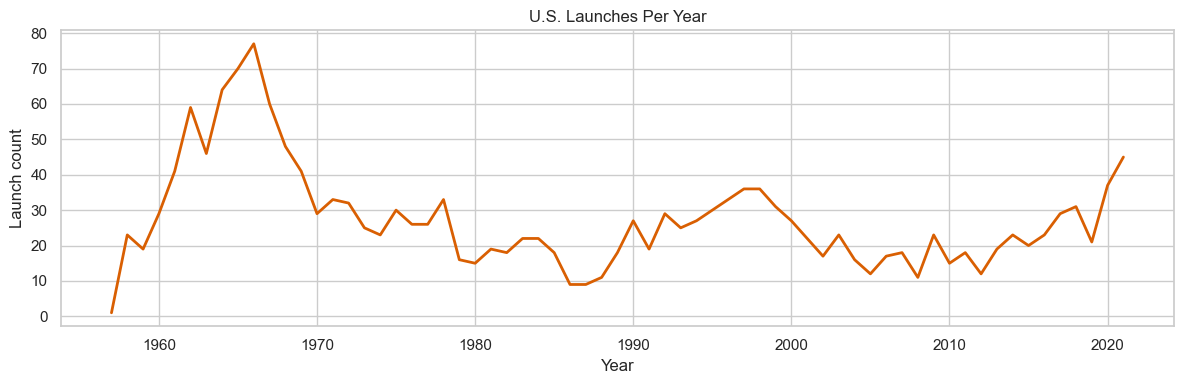

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
us_yearly_counts = us_launches.groupby("launch_year").size()
us_yearly_counts.plot(ax=ax, linewidth=2, color="#d95f02")
ax.set_title("U.S. Launches Per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Launch count")
plt.tight_layout()
plt.show()


## Launch-Site Consolidation

Raw U.S. location strings contain many pad-level variants. For weather joins, the more
useful unit is the facility group. The mapping below keeps Kennedy and Cape Canaveral
separate because they need different practical ZIP proxies.


In [15]:
def infer_us_facility_group(location: str) -> str:
    if "Kennedy Space Center" in location:
        return "Kennedy Space Center"
    if "Cape Canaveral SFS" in location:
        return "Cape Canaveral Space Force Station"
    if "Vandenberg SFB" in location:
        return "Vandenberg Space Force Base"
    if "Wallops Flight Facility" in location:
        return "Wallops Flight Facility"
    if "Pacific Spaceport Complex" in location:
        return "Pacific Spaceport Complex Alaska"
    if "Pacific Missile Range Facility" in location or "Kauai" in location:
        return "Pacific Missile Range Facility"
    if "Mojave Air and Space Port" in location:
        return "Mojave Air and Space Port"
    if "Edwards AFB" in location:
        return "Edwards Air Force Base"
    if "China Lake" in location:
        return "China Lake"
    return "Other U.S. site"


us_launches["facility_group"] = us_launches["Location"].apply(infer_us_facility_group)

us_site_summary = (
    us_launches.groupby("facility_group")
    .agg(
        launches=("Launch Id", "count"),
        raw_location_strings=("Location", "nunique"),
        first_launch=("launch_date", "min"),
        last_launch=("launch_date", "max"),
        success_rate=("Launch Status", lambda s: (s == "Success").mean()),
    )
    .sort_values("launches", ascending=False)
    .reset_index()
)

us_site_summary["success_rate"] = us_site_summary["success_rate"].map(lambda x: f"{x:.1%}")
us_site_summary


,facility_group,launches,raw_location_strings,first_launch,last_launch,success_rate
0,Cape Canaveral Space Force Station,810,22,1957-12-06,2021-12-19,89.0%
1,Vandenberg Space Force Base,711,16,1959-02-28,2021-12-18,89.2%
2,Kennedy Space Center,192,2,1967-11-09,2021-12-21,98.4%
3,Wallops Flight Facility,49,4,1960-12-04,2021-08-10,85.7%
4,Pacific Spaceport Complex Alaska,7,2,2001-09-30,2021-11-20,57.1%
5,China Lake,6,1,1958-07-25,1958-08-28,33.3%
6,Edwards Air Force Base,5,1,1990-04-05,1994-08-03,60.0%
7,Mojave Air and Space Port,3,1,2020-05-25,2021-06-30,66.7%
8,Pacific Missile Range Facility,1,1,2015-11-04,2015-11-04,0.0%


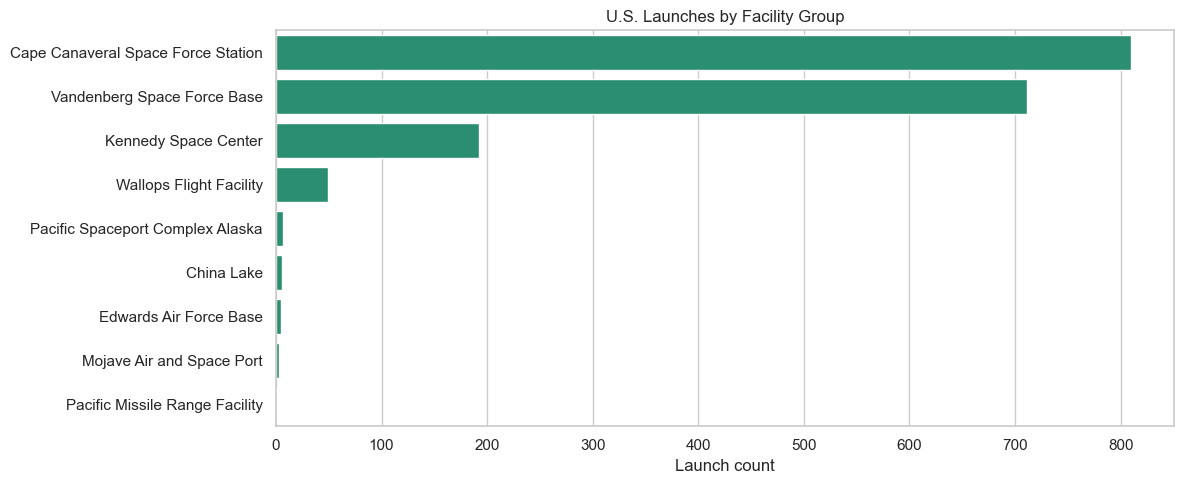

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = (
    us_launches.groupby("facility_group")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="launches")
)
sns.barplot(data=plot_df, y="facility_group", x="launches", ax=ax, color="#1b9e77")
ax.set_title("U.S. Launches by Facility Group")
ax.set_xlabel("Launch count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


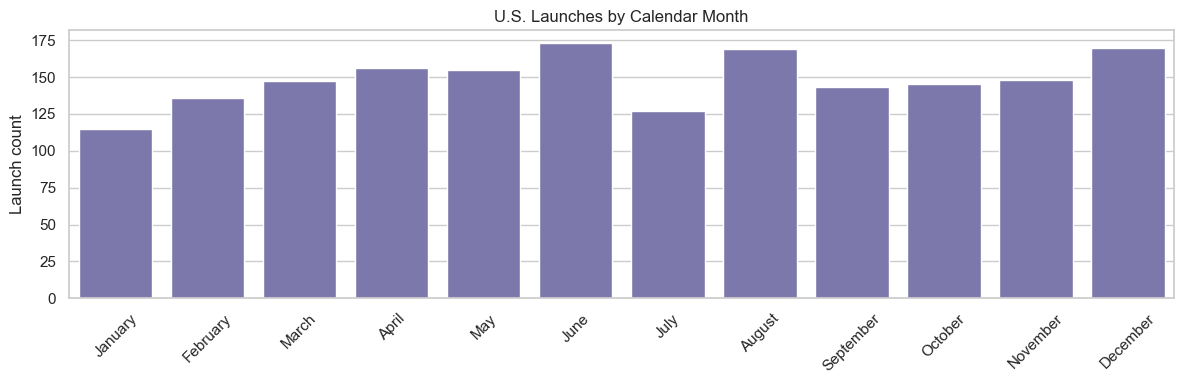

In [17]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_counts = (
    us_launches.groupby("launch_month_name")
    .size()
    .reindex(month_order)
    .reset_index(name="launches")
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=monthly_counts, x="launch_month_name", y="launches", ax=ax, color="#7570b3")
ax.set_title("U.S. Launches by Calendar Month")
ax.set_xlabel("")
ax.set_ylabel("Launch count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Candidate ZIP Codes for NOAA Pulls

The raw data does not contain ZIP codes, so we derive them from latitude/longitude using
`geopy` with Nominatim reverse geocoding. Where reverse geocoding does not return a
postal code, the notebook uses your manual ZIP assignments so every U.S. facility has a
usable NOAA lookup ZIP.


In [18]:
facility_coords = (
    us_launches.groupby("facility_group")
    .agg(
        combined_site_lat=("Comb Launch Site Lat", "first"),
        combined_site_lon=("Comb Launch Site Lon", "first"),
        launches=("Launch Id", "count"),
    )
    .reset_index()
)

geolocator = Nominatim(user_agent="isye6740-rocket-eda")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

def reverse_lookup(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return {"geopy_postcode": None, "geopy_display_name": None}
    try:
        result = reverse((lat, lon), exactly_one=True, language="en")
        if result is None:
            return {"geopy_postcode": None, "geopy_display_name": None}
        return {
            "geopy_postcode": result.raw.get("address", {}).get("postcode"),
            "geopy_display_name": result.address,
        }
    except Exception:
        return {"geopy_postcode": None, "geopy_display_name": None}


geopy_results = facility_coords.apply(
    lambda row: pd.Series(reverse_lookup(row["combined_site_lat"], row["combined_site_lon"])),
    axis=1,
)

zip_reference = pd.concat([facility_coords, geopy_results], axis=1)
zip_reference["geopy_found_zip"] = zip_reference["geopy_postcode"].notna()

zip_reference[
    [
        "facility_group",
        "launches",
        "combined_site_lat",
        "combined_site_lon",
        "geopy_postcode",
        "geopy_found_zip",
    ]
].sort_values("launches", ascending=False)


,facility_group,launches,combined_site_lat,combined_site_lon,geopy_postcode,geopy_found_zip
0,Cape Canaveral Space Force Station,810,28.501081,-80.567792,NaN,False
7,Vandenberg Space Force Base,711,34.698327,-120.585452,93437,True
3,Kennedy Space Center,192,28.501081,-80.567792,NaN,False
8,Wallops Flight Facility,49,37.934371,-75.468544,23337,True
6,Pacific Spaceport Complex Alaska,7,64.200841,-149.493673,NaN,False
1,China Lake,6,35.655171,-117.657437,93555,True
2,Edwards Air Force Base,5,34.992840,-117.883454,NaN,False
4,Mojave Air and Space Port,3,35.056783,-118.157814,93501,True
5,Pacific Missile Range Facility,1,22.035267,-159.781957,NaN,False


In [19]:
manual_zip_overrides = {
    "Cape Canaveral Space Force Station": "32925",
    "Kennedy Space Center": "32899",
    "Edwards Air Force Base": "93524",
    "Pacific Missile Range Facility": "96752",
    "Pacific Spaceport Complex Alaska": "99615",
}

manual_zip_override_df = pd.DataFrame(
    [
        {"facility_group": facility_group, "manual_zip_override": zip_code}
        for facility_group, zip_code in manual_zip_overrides.items()
    ]
)

zip_reference = zip_reference.merge(manual_zip_override_df, on="facility_group", how="left")
zip_reference["candidate_zip"] = zip_reference["geopy_postcode"].fillna(zip_reference["manual_zip_override"])
zip_reference["zip_source"] = zip_reference.apply(
    lambda row: (
        "geopy_reverse"
        if pd.notna(row["geopy_postcode"])
        else "manual_override"
        if pd.notna(row["manual_zip_override"])
        else "missing"
    ),
    axis=1,
)
zip_reference["zip_note"] = zip_reference.apply(
    lambda row: (
        f"Derived from geopy reverse lookup at ({row['combined_site_lat']:.6f}, {row['combined_site_lon']:.6f})."
        if row["zip_source"] == "geopy_reverse"
        else f"User-supplied ZIP override for facility_group={row['facility_group']}."
        if row["zip_source"] == "manual_override"
        else "ZIP missing."
    ),
    axis=1,
)

zip_reference[
    [
        "facility_group",
        "geopy_display_name",
        "geopy_postcode",
        "manual_zip_override",
        "candidate_zip",
        "zip_source",
        "zip_note",
    ]
].sort_values("facility_group")


,facility_group,geopy_display_name,geopy_postcode,manual_zip_override,candidate_zip,zip_source,zip_note
0,Cape Canaveral Space Force Station,"Heavy Launch Road, Brevard County, Florida, United States",NaN,32925,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.
1,China Lake,"North Knox Road, Ridgecrest, Kern County, California, 93555, United States",93555,NaN,93555,geopy_reverse,"Derived from geopy reverse lookup at (35.655171, -117.657437)."
2,Edwards Air Force Base,"B-52, Rosamond Boulevard, Kern County, California, United States",NaN,93524,93524,manual_override,User-supplied ZIP override for facility_group=Edwards Air Force Base.
3,Kennedy Space Center,"Heavy Launch Road, Brevard County, Florida, United States",NaN,32899,32899,manual_override,User-supplied ZIP override for facility_group=Kennedy Space Center.
4,Mojave Air and Space Port,"Old Tower, Flight Line, Kern County, California, 93501, United States",93501,NaN,93501,geopy_reverse,"Derived from geopy reverse lookup at (35.056783, -118.157814)."
5,Pacific Missile Range Facility,"Wai Road, Kauaʻi County, Hawaii, United States",NaN,96752,96752,manual_override,User-supplied ZIP override for facility_group=Pacific Missile Range Facility.
6,Pacific Spaceport Complex Alaska,"Denali Borough, Alaska, United States",NaN,99615,99615,manual_override,User-supplied ZIP override for facility_group=Pacific Spaceport Complex Alaska.
7,Vandenberg Space Force Base,"35th Street, Santa Barbara County, California, 93437, United States",93437,NaN,93437,geopy_reverse,"Derived from geopy reverse lookup at (34.698327, -120.585452)."
8,Wallops Flight Facility,"Wallops Flight Facility, Wallops Neck Road, Wallops Island, Accomack County, Virginia, 23337, United States",23337,NaN,23337,geopy_reverse,"Derived from geopy reverse lookup at (37.934371, -75.468544)."


In [20]:
zip_reference_validation = zip_reference[
    [
        "facility_group",
        "geopy_display_name",
        "geopy_postcode",
        "manual_zip_override",
        "candidate_zip",
        "zip_source",
        "zip_note",
    ]
].sort_values("facility_group")

zip_reference_validation


,facility_group,geopy_display_name,geopy_postcode,manual_zip_override,candidate_zip,zip_source,zip_note
0,Cape Canaveral Space Force Station,"Heavy Launch Road, Brevard County, Florida, United States",NaN,32925,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.
1,China Lake,"North Knox Road, Ridgecrest, Kern County, California, 93555, United States",93555,NaN,93555,geopy_reverse,"Derived from geopy reverse lookup at (35.655171, -117.657437)."
2,Edwards Air Force Base,"B-52, Rosamond Boulevard, Kern County, California, United States",NaN,93524,93524,manual_override,User-supplied ZIP override for facility_group=Edwards Air Force Base.
3,Kennedy Space Center,"Heavy Launch Road, Brevard County, Florida, United States",NaN,32899,32899,manual_override,User-supplied ZIP override for facility_group=Kennedy Space Center.
4,Mojave Air and Space Port,"Old Tower, Flight Line, Kern County, California, 93501, United States",93501,NaN,93501,geopy_reverse,"Derived from geopy reverse lookup at (35.056783, -118.157814)."
5,Pacific Missile Range Facility,"Wai Road, Kauaʻi County, Hawaii, United States",NaN,96752,96752,manual_override,User-supplied ZIP override for facility_group=Pacific Missile Range Facility.
6,Pacific Spaceport Complex Alaska,"Denali Borough, Alaska, United States",NaN,99615,99615,manual_override,User-supplied ZIP override for facility_group=Pacific Spaceport Complex Alaska.
7,Vandenberg Space Force Base,"35th Street, Santa Barbara County, California, 93437, United States",93437,NaN,93437,geopy_reverse,"Derived from geopy reverse lookup at (34.698327, -120.585452)."
8,Wallops Flight Facility,"Wallops Flight Facility, Wallops Neck Road, Wallops Island, Accomack County, Virginia, 23337, United States",23337,NaN,23337,geopy_reverse,"Derived from geopy reverse lookup at (37.934371, -75.468544)."


In [21]:
zip_coverage_summary = pd.DataFrame(
    {
        "metric": [
            "facility groups",
            "facility groups with ZIP assigned",
            "facility groups still missing ZIP",
        ],
        "value": [
            int(zip_reference["facility_group"].nunique()),
            int(zip_reference["candidate_zip"].notna().sum()),
            int(zip_reference["candidate_zip"].isna().sum()),
        ],
    }
)

zip_coverage_summary


,metric,value
0,facility groups,9
1,facility groups with ZIP assigned,9
2,facility groups still missing ZIP,0


In [22]:
us_zip_candidates = (
    us_launches[
        [
            "Location",
            "facility_group",
            "Launch Site",
            "Comb Launch Site",
            "launch_date",
            "Comb Launch Site Lat",
            "Comb Launch Site Lon",
        ]
    ]
    .merge(
        zip_reference[
            [
                "facility_group",
                "candidate_zip",
                "zip_source",
                "zip_note",
            ]
        ],
        on="facility_group",
        how="left",
    )
    .rename(
        columns={
            "Location": "raw_location",
            "Launch Site": "launch_site",
            "Comb Launch Site": "combined_launch_site",
            "Comb Launch Site Lat": "combined_site_lat",
            "Comb Launch Site Lon": "combined_site_lon",
        }
    )
)

zip_site_rollup = (
    us_zip_candidates.groupby(["facility_group", "candidate_zip", "zip_source", "zip_note"])
    .agg(
        launches=("raw_location", "count"),
        raw_location_strings=("raw_location", "nunique"),
        first_launch=("launch_date", "min"),
        last_launch=("launch_date", "max"),
    )
    .reset_index()
    .sort_values("launches", ascending=False)
)

zip_site_rollup


,facility_group,candidate_zip,zip_source,zip_note,launches,raw_location_strings,first_launch,last_launch
0,Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,810,22,1957-12-06,2021-12-19
7,Vandenberg Space Force Base,93437,geopy_reverse,"Derived from geopy reverse lookup at (34.698327, -120.585452).",711,16,1959-02-28,2021-12-18
3,Kennedy Space Center,32899,manual_override,User-supplied ZIP override for facility_group=Kennedy Space Center.,192,2,1967-11-09,2021-12-21
8,Wallops Flight Facility,23337,geopy_reverse,"Derived from geopy reverse lookup at (37.934371, -75.468544).",49,4,1960-12-04,2021-08-10
6,Pacific Spaceport Complex Alaska,99615,manual_override,User-supplied ZIP override for facility_group=Pacific Spaceport Complex Alaska.,7,2,2001-09-30,2021-11-20
1,China Lake,93555,geopy_reverse,"Derived from geopy reverse lookup at (35.655171, -117.657437).",6,1,1958-07-25,1958-08-28
2,Edwards Air Force Base,93524,manual_override,User-supplied ZIP override for facility_group=Edwards Air Force Base.,5,1,1990-04-05,1994-08-03
4,Mojave Air and Space Port,93501,geopy_reverse,"Derived from geopy reverse lookup at (35.056783, -118.157814).",3,1,2020-05-25,2021-06-30
5,Pacific Missile Range Facility,96752,manual_override,User-supplied ZIP override for facility_group=Pacific Missile Range Facility.,1,1,2015-11-04,2015-11-04


In [23]:
raw_location_zip_map = (
    us_zip_candidates[
        [
            "raw_location",
            "facility_group",
            "candidate_zip",
            "zip_source",
            "zip_note",
            "launch_site",
            "combined_launch_site",
            "combined_site_lat",
            "combined_site_lon",
        ]
    ]
    .drop_duplicates()
    .sort_values(["facility_group", "raw_location"])
    .reset_index(drop=True)
)

raw_location_zip_map


,raw_location,facility_group,candidate_zip,zip_source,zip_note,launch_site,combined_launch_site,combined_site_lat,combined_site_lon
0,"LC-11, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
1,"LC-12, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
2,"LC-13, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
3,"LC-14, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
4,"LC-18A, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
5,"LC-18B, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
6,"LC-19, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
7,"LC-26A, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
8,"LC-26B, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792
9,"LC-34, Cape Canaveral SFS, Florida, USA",Cape Canaveral Space Force Station,32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.,Cape Canaveral SFS,Cape Canaveral SFS/Kennedy SC,28.501081,-80.567792


## Temporal Extraction Plan

For NOAA pulls, the minimum workable extraction key is the launch date plus the resolved
facility ZIP. This table gives the facility-level date windows that matter.


In [24]:
noaa_pull_plan = (
    us_launches.groupby("facility_group")
    .agg(
        launches=("Launch Id", "count"),
        min_launch_date=("launch_date", "min"),
        max_launch_date=("launch_date", "max"),
        statuses=("Launch Status", lambda s: ", ".join(sorted(s.unique()))),
    )
    .reset_index()
    .merge(
        zip_reference[
            [
                "facility_group",
                "candidate_zip",
                "zip_source",
                "zip_note",
            ]
        ],
        on="facility_group",
        how="left",
    )
    .sort_values("launches", ascending=False)
)

noaa_pull_plan


,facility_group,launches,min_launch_date,max_launch_date,statuses,candidate_zip,zip_source,zip_note
0,Cape Canaveral Space Force Station,810,1957-12-06,2021-12-19,"Failure, Partial Failure, Prelaunch Failure, Success",32925,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.
7,Vandenberg Space Force Base,711,1959-02-28,2021-12-18,"Failure, Partial Failure, Success",93437,geopy_reverse,"Derived from geopy reverse lookup at (34.698327, -120.585452)."
3,Kennedy Space Center,192,1967-11-09,2021-12-21,"Failure, Partial Failure, Success",32899,manual_override,User-supplied ZIP override for facility_group=Kennedy Space Center.
8,Wallops Flight Facility,49,1960-12-04,2021-08-10,"Failure, Partial Failure, Success",23337,geopy_reverse,"Derived from geopy reverse lookup at (37.934371, -75.468544)."
6,Pacific Spaceport Complex Alaska,7,2001-09-30,2021-11-20,"Failure, Success",99615,manual_override,User-supplied ZIP override for facility_group=Pacific Spaceport Complex Alaska.
1,China Lake,6,1958-07-25,1958-08-28,"Failure, Success",93555,geopy_reverse,"Derived from geopy reverse lookup at (35.655171, -117.657437)."
2,Edwards Air Force Base,5,1990-04-05,1994-08-03,"Partial Failure, Success",93524,manual_override,User-supplied ZIP override for facility_group=Edwards Air Force Base.
4,Mojave Air and Space Port,3,2020-05-25,2021-06-30,"Failure, Success",93501,geopy_reverse,"Derived from geopy reverse lookup at (35.056783, -118.157814)."
5,Pacific Missile Range Facility,1,2015-11-04,2015-11-04,Failure,96752,manual_override,User-supplied ZIP override for facility_group=Pacific Missile Range Facility.


## Data Quality Notes

The launch-weather join is feasible, but a few issues should be handled deliberately:
1. ZIP codes are not in the raw data and must be derived.
2. Some ZIP codes come directly from `geopy` reverse geocoding, while others are supplied
   manually in `manual_zip_overrides` when geocoding does not return a postal code.
3. `Locations.csv` appears to have at least one suspicious coordinate pair:
   `Pacific Spaceport Complex, Kodiak, Alaska` is associated with inland Alaska
   coordinates in the source file, so that site should be validated before any
   location-sensitive weather extraction.
4. The dataset is entirely orbital launches, which simplifies the target population but
   means suborbital weather effects are out of scope here.


In [25]:
suspicious_locations = locations[
    locations["Orig_Addr"].str.contains("Pacific Spaceport Complex", na=False)
][
    [
        "Orig_Addr",
        "Lat",
        "Lon",
        "Launch Site",
        "Comb Launch Site",
        "Comb Launch Site Lat",
        "Comb Launch Site Lon",
    ]
]

suspicious_locations


,Orig_Addr,Lat,Lon,Launch Site,Comb Launch Site,Comb Launch Site Lat,Comb Launch Site Lon
81,"LP-3B, Pacific Spaceport Complex, Kodiak, Alaska, USA",64.200841,-149.493673,Pacific SC,Pacific SC,64.200841,-149.493673
82,"LP-1, Pacific Spaceport Complex, Kodiak, Alaska, USA",64.200841,-149.493673,Pacific SC,Pacific SC,64.200841,-149.493673


## Final NOAA Pull Reference

This is the main lookup table for weather extraction. Use one row per facility group to
determine the ZIP code and inclusive date range to pull from NOAA.


In [26]:
final_noaa_pull_reference = (
    noaa_pull_plan[
        [
            "facility_group",
            "candidate_zip",
            "min_launch_date",
            "max_launch_date",
            "launches",
            "zip_source",
            "zip_note",
        ]
    ]
    .rename(
        columns={
            "facility_group": "facility",
            "candidate_zip": "zip_code",
            "min_launch_date": "date_from",
            "max_launch_date": "date_to",
            "zip_source": "zip_assignment_method",
            "zip_note": "zip_note",
        }
    )
    .sort_values(["facility"])
    .reset_index(drop=True)
)

final_noaa_pull_reference


,facility,zip_code,date_from,date_to,launches,zip_assignment_method,zip_note
0,Cape Canaveral Space Force Station,32925,1957-12-06,2021-12-19,810,manual_override,User-supplied ZIP override for facility_group=Cape Canaveral Space Force Station.
1,China Lake,93555,1958-07-25,1958-08-28,6,geopy_reverse,"Derived from geopy reverse lookup at (35.655171, -117.657437)."
2,Edwards Air Force Base,93524,1990-04-05,1994-08-03,5,manual_override,User-supplied ZIP override for facility_group=Edwards Air Force Base.
3,Kennedy Space Center,32899,1967-11-09,2021-12-21,192,manual_override,User-supplied ZIP override for facility_group=Kennedy Space Center.
4,Mojave Air and Space Port,93501,2020-05-25,2021-06-30,3,geopy_reverse,"Derived from geopy reverse lookup at (35.056783, -118.157814)."
5,Pacific Missile Range Facility,96752,2015-11-04,2015-11-04,1,manual_override,User-supplied ZIP override for facility_group=Pacific Missile Range Facility.
6,Pacific Spaceport Complex Alaska,99615,2001-09-30,2021-11-20,7,manual_override,User-supplied ZIP override for facility_group=Pacific Spaceport Complex Alaska.
7,Vandenberg Space Force Base,93437,1959-02-28,2021-12-18,711,geopy_reverse,"Derived from geopy reverse lookup at (34.698327, -120.585452)."
8,Wallops Flight Facility,23337,1960-12-04,2021-08-10,49,geopy_reverse,"Derived from geopy reverse lookup at (37.934371, -75.468544)."


## LCD Weather Merge

The LCD weather files mix hourly, daily, and monthly rows. For the launch-weather merge,
we keep only the strongest hourly observation at each timestamp, convert each launch time
from UTC into the facility's **local standard time** (matching NOAA LCD conventions), and
then match to the nearest hourly weather record within a 2-hour window.


In [27]:
def clean_lcd_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.extract(r"([-+]?[0-9]*\.?[0-9]+)")[0],
        errors="coerce",
    )


def load_best_hourly_weather(rel_path: str) -> pd.DataFrame:
    weather_raw = pd.read_csv(DATA_DIR / rel_path, low_memory=False)
    keep_cols = ["DATE", "REPORT_TYPE"] + [
        c
        for c in WEATHER_NUMERIC_COLUMNS + WEATHER_TEXT_COLUMNS + SHORT_DURATION_PRECIP_COLUMNS
        if c in weather_raw.columns
    ]
    weather = weather_raw[keep_cols].copy()

    for col in [c for c in WEATHER_NUMERIC_COLUMNS + SHORT_DURATION_PRECIP_COLUMNS if c in weather.columns]:
        weather[col] = clean_lcd_numeric(weather[col])

    weather["weather_obs_time_lstd"] = pd.to_datetime(weather["DATE"], errors="coerce")
    weather = weather.dropna(subset=["weather_obs_time_lstd"]).copy()

    numeric_cols = [c for c in WEATHER_NUMERIC_COLUMNS if c in weather.columns]
    text_cols = [c for c in WEATHER_TEXT_COLUMNS if c in weather.columns]

    weather["hourly_nonnulls"] = weather[numeric_cols].notna().sum(axis=1)
    for col in text_cols:
        weather["hourly_nonnulls"] += weather[col].notna().astype(int)

    weather = (
        weather.loc[weather["hourly_nonnulls"] > 0]
        .sort_values(["weather_obs_time_lstd", "hourly_nonnulls"], ascending=[True, False])
        .drop_duplicates(subset=["weather_obs_time_lstd"], keep="first")
        .sort_values("weather_obs_time_lstd")
        .reset_index(drop=True)
    )

    present_weather = weather.get("HourlyPresentWeatherType", pd.Series("", index=weather.index)).fillna("").astype(str)
    sky_conditions = weather.get("HourlySkyConditions", pd.Series("", index=weather.index)).fillna("").astype(str)

    weather["present_weather_rain_flag"] = present_weather.str.contains(r"RA|DZ|SH", regex=True)
    weather["present_weather_fog_flag"] = present_weather.str.contains(r"FG|BR|HZ", regex=True)
    weather["present_weather_thunder_flag"] = present_weather.str.contains(r"TS", regex=True)
    weather["cloud_cover_broken_or_overcast_flag"] = sky_conditions.str.contains(r"BKN|OVC", regex=True)

    available_short_duration_cols = [c for c in SHORT_DURATION_PRECIP_COLUMNS if c in weather.columns]
    if available_short_duration_cols:
        weather["short_duration_precip_max"] = weather[available_short_duration_cols].max(axis=1, skipna=True)
    else:
        weather["short_duration_precip_max"] = float("nan")

    return weather


weather_merges = []
weather_coverage_rows = []

for facility, (rel_path, utc_offset_hours) in WEATHER_FILE_MAP.items():
    facility_launches = us_launches.loc[us_launches["facility_group"] == facility].copy()
    facility_launches["launch_time_lstd"] = (
        facility_launches["launch_time_utc"] + pd.to_timedelta(utc_offset_hours, unit="h")
    ).dt.tz_localize(None)
    facility_launches = facility_launches.sort_values("launch_time_lstd")

    weather = load_best_hourly_weather(rel_path)

    merged = pd.merge_asof(
        facility_launches,
        weather,
        left_on="launch_time_lstd",
        right_on="weather_obs_time_lstd",
        direction="nearest",
        tolerance=pd.Timedelta("2h"),
    )

    merged["weather_matched"] = merged["weather_obs_time_lstd"].notna()
    merged["weather_time_diff_minutes"] = (
        (merged["launch_time_lstd"] - merged["weather_obs_time_lstd"]).dt.total_seconds().abs() / 60
    )

    weather_coverage_rows.append(
        {
            "facility_group": facility,
            "launches": len(facility_launches),
            "matched_launches": int(merged["weather_matched"].sum()),
            "match_rate": merged["weather_matched"].mean(),
            "median_abs_diff_minutes": merged["weather_time_diff_minutes"].median(),
            "weather_start_lstd": weather["weather_obs_time_lstd"].min(),
            "weather_end_lstd": weather["weather_obs_time_lstd"].max(),
        }
    )

    weather_merges.append(merged)

us_launch_weather = pd.concat(weather_merges, ignore_index=True)
us_launch_weather["launch_outcome_group"] = us_launch_weather["Launch Status"].where(
    us_launch_weather["Launch Status"] == "Success",
    "Not Success",
)
us_launch_weather["launch_success_binary"] = (us_launch_weather["Launch Status"] == "Success").astype(int)
us_launch_weather["launch_failure_binary"] = (us_launch_weather["Launch Status"] != "Success").astype(int)
us_launch_weather["precip_positive_flag"] = us_launch_weather["HourlyPrecipitation"].fillna(0).gt(0)
us_launch_weather["weather_type_reported_flag"] = (
    us_launch_weather["HourlyPresentWeatherType"].fillna("").astype(str).str.len().gt(0)
)
us_launch_weather["high_wind_flag"] = us_launch_weather["HourlyWindSpeed"].ge(15)
us_launch_weather["low_visibility_flag"] = us_launch_weather["HourlyVisibility"].le(5)
us_launch_weather["launch_year"] = us_launch_weather["launch_time_utc"].dt.year
us_launch_weather["launch_decade"] = (us_launch_weather["launch_year"] // 10) * 10
us_launch_weather["rocket_payload_leo"] = pd.to_numeric(
    us_launch_weather["Rocket Payload to LEO"], errors="coerce"
)
us_launch_weather["rocket_price_musd"] = pd.to_numeric(us_launch_weather["Rocket Price"], errors="coerce")
us_launch_weather["rocket_price_adjusted_musd"] = pd.to_numeric(
    us_launch_weather["Rocket Price CPI Adjusted"], errors="coerce"
)
us_launch_weather["usd_per_kg_leo_adjusted"] = pd.to_numeric(
    us_launch_weather["USD/kg to LEO CPI Adjusted"], errors="coerce"
)
us_launch_weather["is_partial_failure"] = (us_launch_weather["Launch Status"] == "Partial Failure").astype(int)
us_launch_weather["is_failure"] = (us_launch_weather["Launch Status"] == "Failure").astype(int)
us_launch_weather["is_prelaunch_failure"] = (
    us_launch_weather["Launch Status"] == "Prelaunch Failure"
).astype(int)

top_orgs = us_launch_weather["Rocket Organisation"].value_counts().head(8).index
us_launch_weather["rocket_org_grouped"] = us_launch_weather["Rocket Organisation"].where(
    us_launch_weather["Rocket Organisation"].isin(top_orgs),
    "Other",
)

payload_bin_edges = [0, 500, 2000, 10000, 50000, 500000]
us_launch_weather["payload_bin"] = pd.cut(
    us_launch_weather["rocket_payload_leo"],
    bins=payload_bin_edges,
    include_lowest=True,
)

weather_merge_coverage = (
    pd.DataFrame(weather_coverage_rows)
    .sort_values("matched_launches", ascending=False)
    .reset_index(drop=True)
)

weather_merge_coverage


,facility_group,launches,matched_launches,match_rate,median_abs_diff_minutes,weather_start_lstd,weather_end_lstd
0,Vandenberg Space Force Base,711,672,0.945148,13.0,1959-01-01 00:00:00,2021-12-31 23:58:00
1,Cape Canaveral Space Force Station,810,509,0.628395,14.0,1957-12-01 00:00:00,2021-12-31 23:56:00
2,Kennedy Space Center,192,173,0.901042,0.0,1978-03-16 19:00:00,2021-12-31 23:56:00
3,Wallops Flight Facility,49,35,0.714286,13.0,1966-10-01 07:00:00,2021-12-31 23:54:00
4,Pacific Spaceport Complex Alaska,7,7,1.000000,16.0,2001-01-01 00:42:00,2021-12-31 23:56:00
5,China Lake,6,6,1.000000,0.0,1958-01-01 00:00:00,1958-12-31 23:00:00
6,Edwards Air Force Base,5,5,1.000000,10.0,1990-01-02 05:10:00,1994-12-30 16:00:00
7,Mojave Air and Space Port,3,2,0.666667,6.0,2020-01-01 00:00:00,2021-12-28 13:20:00
8,Pacific Missile Range Facility,1,1,1.000000,11.0,2015-01-01 00:56:00,2015-12-31 23:56:00


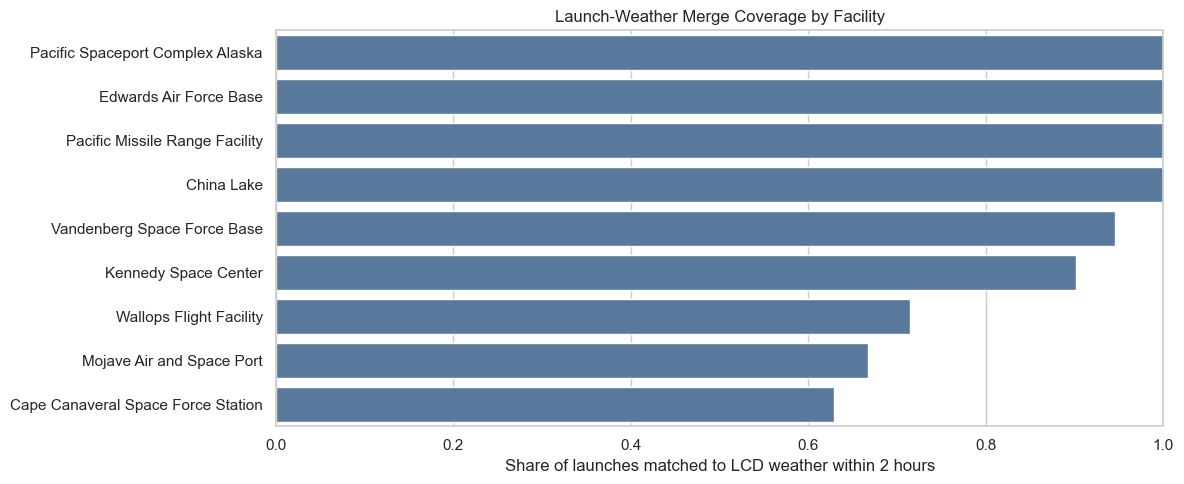

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_df = weather_merge_coverage.sort_values("match_rate", ascending=False)
sns.barplot(data=plot_df, x="match_rate", y="facility_group", ax=ax, color="#4c78a8")
ax.set_title("Launch-Weather Merge Coverage by Facility")
ax.set_xlabel("Share of launches matched to LCD weather within 2 hours")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## Weather Feature Coverage

Before comparing outcomes, it is important to see which LCD features are broadly available
after the merge and which are sparse enough to be unreliable for first-pass modeling.


In [29]:
matched_launch_weather = us_launch_weather.loc[us_launch_weather["weather_matched"]].copy()

weather_feature_availability = pd.DataFrame(
    {
        "feature": WEATHER_NUMERIC_COLUMNS
        + WEATHER_TEXT_COLUMNS
        + [
            "present_weather_rain_flag",
            "present_weather_fog_flag",
            "present_weather_thunder_flag",
            "cloud_cover_broken_or_overcast_flag",
            "short_duration_precip_max",
        ],
        "non_null_share": [
            matched_launch_weather[col].notna().mean() if col in matched_launch_weather.columns else 0
            for col in WEATHER_NUMERIC_COLUMNS
            + WEATHER_TEXT_COLUMNS
            + [
                "present_weather_rain_flag",
                "present_weather_fog_flag",
                "present_weather_thunder_flag",
                "cloud_cover_broken_or_overcast_flag",
                "short_duration_precip_max",
            ]
        ],
    }
).sort_values("non_null_share", ascending=False)

weather_feature_availability


,feature,non_null_share
17,cloud_cover_broken_or_overcast_flag,1.000000
16,present_weather_thunder_flag,1.000000
15,present_weather_fog_flag,1.000000
14,present_weather_rain_flag,1.000000
9,HourlyWindSpeed,0.983688
1,HourlyDryBulbTemperature,0.981560
11,HourlyWindDirection,0.902128
3,HourlyRelativeHumidity,0.901418
2,HourlyDewPointTemperature,0.901418
7,HourlySeaLevelPressure,0.797872


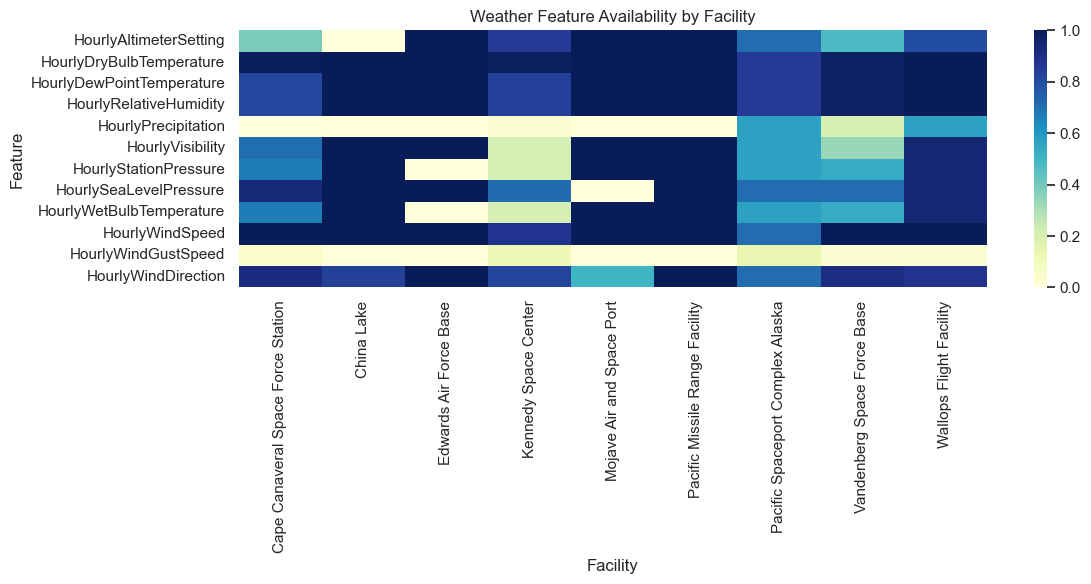

In [30]:
facility_feature_availability = (
    matched_launch_weather.groupby("facility_group")[
        [c for c in WEATHER_NUMERIC_COLUMNS if c in matched_launch_weather.columns]
    ]
    .agg(lambda s: s.notna().mean())
    .T
)

plt.figure(figsize=(12, 6))
sns.heatmap(facility_feature_availability, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Weather Feature Availability by Facility")
plt.xlabel("Facility")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Launch Features in Scope

Weather is only part of the story. The merged event table also retains launch-side
variables such as operator, payload capacity, rocket price, and launch year so the EDA
can distinguish weather patterns from baseline launch-vehicle differences.


In [31]:
launch_feature_availability = pd.DataFrame(
    {
        "feature": [
            "payload_count",
            "mission_mass",
            "mission_rows",
            "rocket_payload_leo",
            "rocket_price_musd",
            "rocket_price_adjusted_musd",
            "usd_per_kg_leo_adjusted",
            "rocket_family",
            "config_status",
            "config_liftoff_thrust",
            "config_payload_leo",
            "config_payload_gto",
            "config_stages",
            "config_strap_ons",
            "config_rocket_height",
            "config_fairing_diameter",
            "config_fairing_height",
            "family_success_rate_pct",
            "Rocket Organisation",
            "Rocket Name",
        ],
        "non_null_share": [
            us_launch_weather["payload_count"].notna().mean(),
            us_launch_weather["mission_mass"].notna().mean(),
            us_launch_weather["mission_rows"].notna().mean(),
            us_launch_weather["rocket_payload_leo"].notna().mean(),
            us_launch_weather["rocket_price_musd"].notna().mean(),
            us_launch_weather["rocket_price_adjusted_musd"].notna().mean(),
            us_launch_weather["usd_per_kg_leo_adjusted"].notna().mean(),
            us_launch_weather["rocket_family"].notna().mean(),
            us_launch_weather["config_status"].notna().mean(),
            us_launch_weather["config_liftoff_thrust"].notna().mean(),
            us_launch_weather["config_payload_leo"].notna().mean(),
            us_launch_weather["config_payload_gto"].notna().mean(),
            us_launch_weather["config_stages"].notna().mean(),
            us_launch_weather["config_strap_ons"].notna().mean(),
            us_launch_weather["config_rocket_height"].notna().mean(),
            us_launch_weather["config_fairing_diameter"].notna().mean(),
            us_launch_weather["config_fairing_height"].notna().mean(),
            us_launch_weather["family_success_rate_pct"].notna().mean(),
            us_launch_weather["Rocket Organisation"].notna().mean(),
            us_launch_weather["Rocket Name"].notna().mean(),
        ],
    }
)

launch_feature_availability


,feature,non_null_share
0,payload_count,0.662556
1,mission_mass,0.662556
2,mission_rows,0.662556
3,rocket_payload_leo,0.627803
4,rocket_price_musd,0.302691
5,rocket_price_adjusted_musd,0.302691
6,usd_per_kg_leo_adjusted,0.297085
7,rocket_family,1.000000
8,config_status,1.000000
9,config_liftoff_thrust,0.678251


In [32]:
launch_feature_outcome_summary = []
for feature in [
    "payload_count",
    "mission_mass",
    "rocket_payload_leo",
    "rocket_price_musd",
    "rocket_price_adjusted_musd",
    "usd_per_kg_leo_adjusted",
    "config_liftoff_thrust",
    "config_stages",
    "config_strap_ons",
    "family_success_rate_pct",
    "launch_year",
]:
    temp = (
        us_launch_weather.groupby("launch_outcome_group")[feature]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    temp["feature"] = feature
    launch_feature_outcome_summary.append(temp)

launch_feature_outcome_summary = pd.concat(launch_feature_outcome_summary, ignore_index=True)
launch_feature_outcome_summary


,launch_outcome_group,count,mean,median,std,feature
0,Not Success,102,1.686275,1.000000,3.469757,payload_count
1,Success,1080,3.268519,1.000000,11.410129,payload_count
2,Not Success,102,1468.480392,31.500000,4124.952456,mission_mass
3,Success,1080,3708.437963,840.000000,6460.468734,mission_mass
4,Not Success,106,5216.933962,1250.000000,14714.019027,rocket_payload_leo
5,Success,1014,12816.431953,8640.000000,17229.560726,rocket_payload_leo
6,Not Success,29,121.873448,45.000000,232.774328,rocket_price_musd
7,Success,511,205.248513,109.000000,224.059525,rocket_price_musd
8,Not Success,29,491.078999,70.222719,1663.141295,rocket_price_adjusted_musd
9,Success,511,502.406178,129.836005,1247.910575,rocket_price_adjusted_musd


In [33]:
rocket_org_outcomes = (
    us_launch_weather.groupby("rocket_org_grouped")
    .agg(
        launches=("Launch Id", "count"),
        success_rate=("launch_success_binary", "mean"),
    )
    .sort_values("launches", ascending=False)
    .reset_index()
)

rocket_org_outcomes


,rocket_org_grouped,launches,success_rate
0,US Air Force,548,0.888686
1,General Dynamics,250,0.812000
2,NASA,204,0.941176
3,Other,164,0.786585
4,ULA,147,0.993197
5,Boeing,138,0.963768
6,SpaceX,137,0.978102
7,Martin Marietta,114,0.877193
8,Northrop,82,0.890244


In [34]:
rocket_family_outcomes = (
    us_launch_weather.groupby("rocket_family")
    .agg(
        launches=("Launch Id", "count"),
        success_rate=("launch_success_binary", "mean"),
    )
    .sort_values("launches", ascending=False)
    .head(15)
    .reset_index()
)

config_status_outcomes = (
    us_launch_weather.groupby("config_status")
    .agg(
        launches=("Launch Id", "count"),
        success_rate=("launch_success_binary", "mean"),
    )
    .sort_values("launches", ascending=False)
    .reset_index()
)

rocket_family_outcomes


,rocket_family,launches,success_rate
0,Thor-Agena,185,0.864865
1,Titan III,156,0.891026
2,Delta II,155,0.987097
3,Space Shuttle,135,0.985185
4,Falcon 9,134,0.977612
5,Atlas-Agena,109,0.816514
6,Atlas V,90,0.988889
7,Scout,90,0.855556
8,Atlas-Centaur,67,0.820896
9,Atlas II,63,1.000000


In [35]:
config_status_outcomes


,config_status,launches,success_rate
0,Retired,1547,0.888171
1,Active,237,0.940928


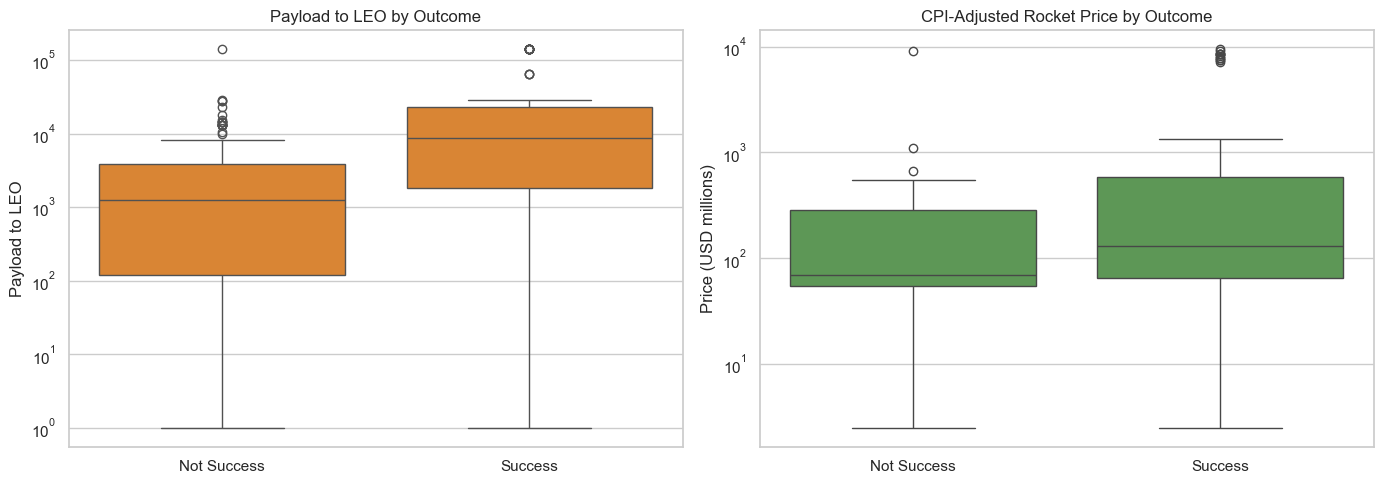

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=us_launch_weather,
    x="launch_outcome_group",
    y="rocket_payload_leo",
    ax=axes[0],
    color="#f58518",
)
axes[0].set_title("Payload to LEO by Outcome")
axes[0].set_xlabel("")
axes[0].set_ylabel("Payload to LEO")
axes[0].set_yscale("log")

sns.boxplot(
    data=us_launch_weather,
    x="launch_outcome_group",
    y="rocket_price_adjusted_musd",
    ax=axes[1],
    color="#54a24b",
)
axes[1].set_title("CPI-Adjusted Rocket Price by Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price (USD millions)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


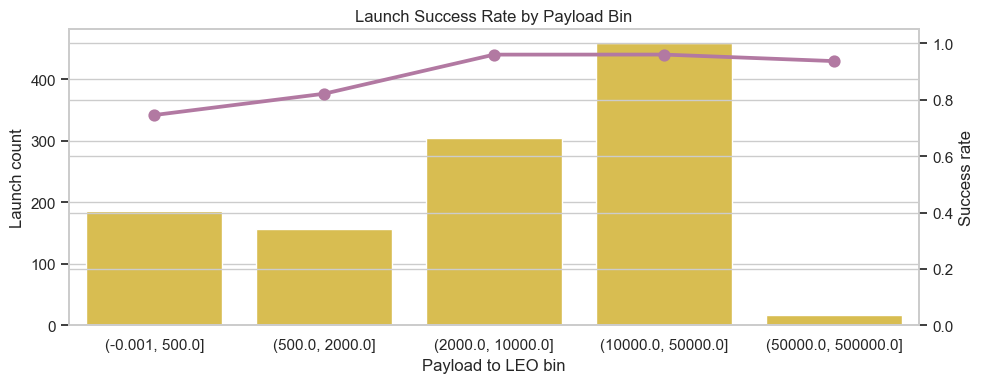

,payload_bin,launches,success_rate
0,"(-0.001, 500.0]",185,0.745946
1,"(500.0, 2000.0]",157,0.821656
2,"(2000.0, 10000.0]",304,0.960526
3,"(10000.0, 50000.0]",458,0.960699
4,"(50000.0, 500000.0]",16,0.937500


In [37]:
payload_success_profile = (
    us_launch_weather.dropna(subset=["payload_bin"])
    .groupby("payload_bin", observed=False)
    .agg(
        launches=("Launch Id", "count"),
        success_rate=("launch_success_binary", "mean"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(data=payload_success_profile, x="payload_bin", y="launches", ax=ax1, color="#eeca3b")
ax1.set_ylabel("Launch count")
ax1.set_xlabel("Payload to LEO bin")
ax1.set_title("Launch Success Rate by Payload Bin")

ax2 = ax1.twinx()
sns.pointplot(data=payload_success_profile, x="payload_bin", y="success_rate", ax=ax2, color="#b279a2")
ax2.set_ylabel("Success rate")
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

payload_success_profile


## Weather vs. Launch Outcome

The dataset is highly imbalanced toward successful launches, so the comparisons below are
descriptive EDA rather than causal conclusions. The goal is to surface patterns worth
testing later in formal modeling.


In [38]:
weather_by_outcome_summary = []
for feature in [
    "HourlyAltimeterSetting",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlySeaLevelPressure",
    "HourlyWetBulbTemperature",
    "HourlyWindSpeed",
    "short_duration_precip_max",
]:
    temp = (
        matched_launch_weather.groupby("launch_outcome_group")[feature]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    temp["feature"] = feature
    weather_by_outcome_summary.append(temp)

weather_by_outcome_summary = pd.concat(weather_by_outcome_summary, ignore_index=True)
weather_by_outcome_summary


,launch_outcome_group,count,mean,median,std,feature
0,Not Success,40,30.036000,30.03,0.139978,HourlyAltimeterSetting
1,Success,665,30.048271,30.04,0.136312,HourlyAltimeterSetting
2,Not Success,158,65.563291,63.00,13.134015,HourlyDryBulbTemperature
3,Success,1226,64.666395,63.50,12.361050,HourlyDryBulbTemperature
4,Not Success,155,54.748387,53.00,12.861699,HourlyDewPointTemperature
5,Success,1116,54.557348,53.00,12.684277,HourlyDewPointTemperature
6,Not Success,155,72.709677,76.00,19.293013,HourlyRelativeHumidity
7,Success,1116,74.760753,77.00,17.446526,HourlyRelativeHumidity
8,Not Success,116,12.130862,9.94,6.756346,HourlyVisibility
9,Success,552,9.908587,9.94,4.665645,HourlyVisibility


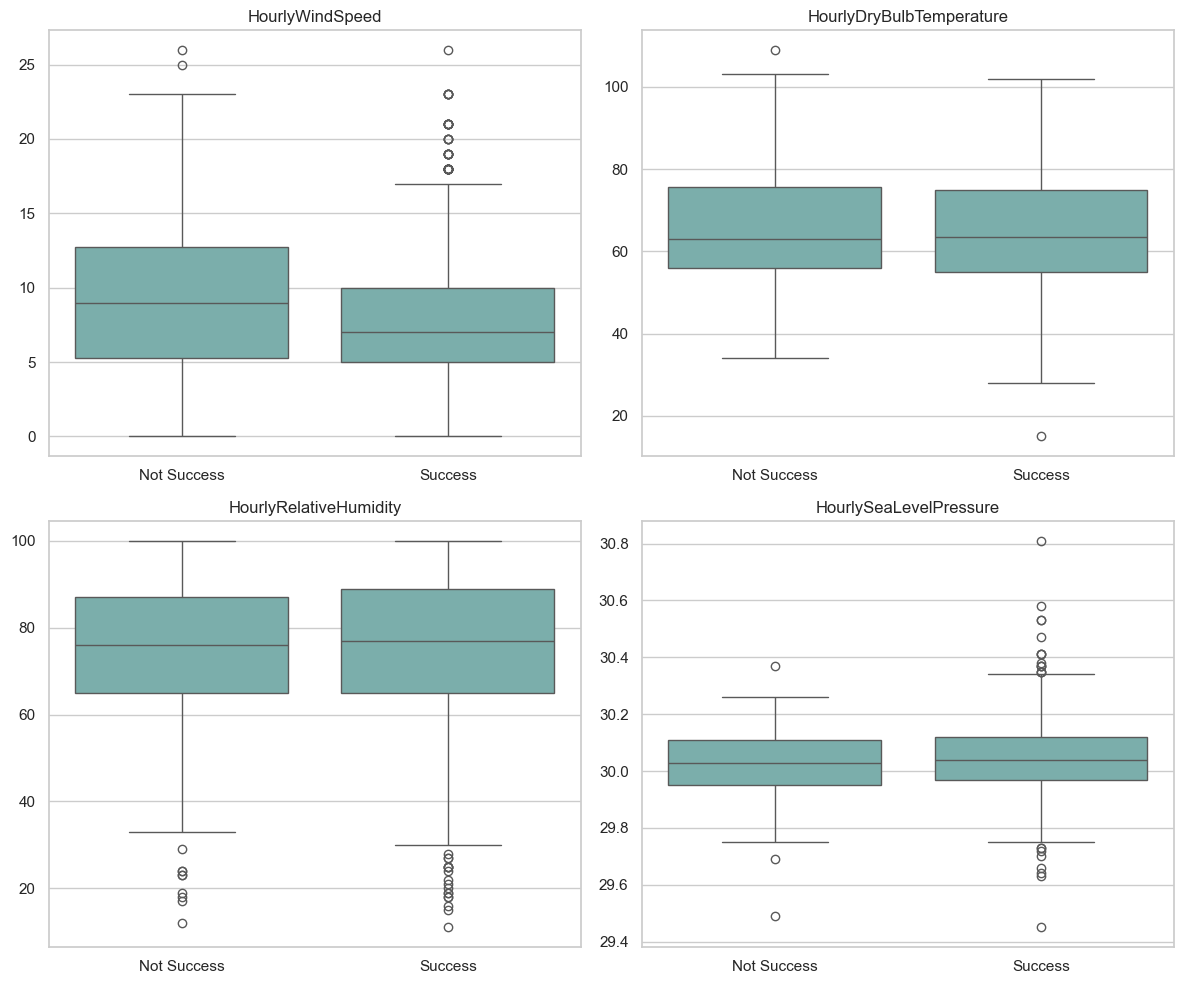

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
feature_list = [
    "HourlyWindSpeed",
    "HourlyDryBulbTemperature",
    "HourlyRelativeHumidity",
    "HourlySeaLevelPressure",
]

for ax, feature in zip(axes.flatten(), feature_list):
    sns.boxplot(
        data=matched_launch_weather,
        x="launch_outcome_group",
        y=feature,
        ax=ax,
        color="#72b7b2",
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [40]:
outcome_indicator_summary = pd.DataFrame(
    {
        "metric": [
            "precip_positive_share",
            "weather_type_reported_share",
            "high_wind_share",
            "low_visibility_share",
            "rain_code_share",
            "fog_code_share",
            "thunder_code_share",
            "broken_or_overcast_share",
        ],
        "Not Success": [
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "precip_positive_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "weather_type_reported_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "high_wind_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "low_visibility_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "present_weather_rain_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "present_weather_fog_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "present_weather_thunder_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Not Success",
                "cloud_cover_broken_or_overcast_flag",
            ].mean(),
        ],
        "Success": [
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "precip_positive_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "weather_type_reported_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "high_wind_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "low_visibility_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "present_weather_rain_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "present_weather_fog_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "present_weather_thunder_flag",
            ].mean(),
            matched_launch_weather.loc[
                matched_launch_weather["launch_outcome_group"] == "Success",
                "cloud_cover_broken_or_overcast_flag",
            ].mean(),
        ],
    }
)

outcome_indicator_summary


,metric,Not Success,Success
0,precip_positive_share,0.006289,0.000000
1,weather_type_reported_share,0.515723,0.432454
2,high_wind_share,0.169811,0.092726
3,low_visibility_share,0.025157,0.045564
4,rain_code_share,0.012579,0.017586
5,fog_code_share,0.031447,0.091926
6,thunder_code_share,0.000000,0.003197
7,broken_or_overcast_share,0.088050,0.085532


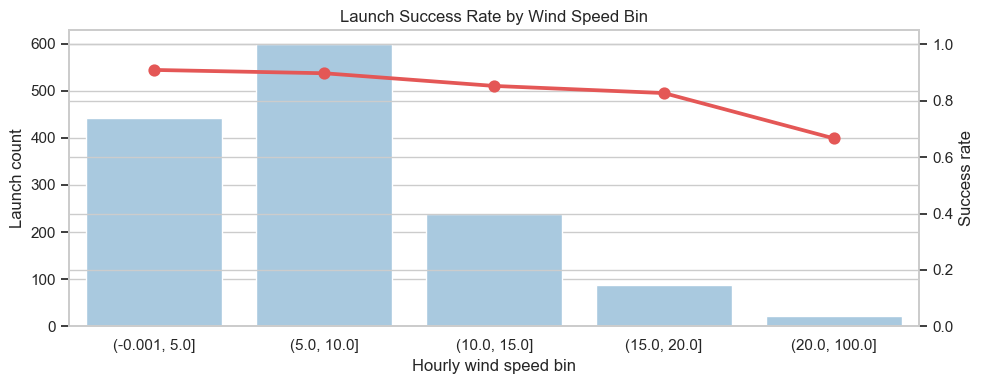

,wind_speed_bin,launches,success_rate
0,"(-0.001, 5.0]",443,0.909707
1,"(5.0, 10.0]",598,0.897993
2,"(10.0, 15.0]",238,0.852941
3,"(15.0, 20.0]",87,0.827586
4,"(20.0, 100.0]",21,0.666667


In [41]:
wind_bin_edges = [0, 5, 10, 15, 20, 100]
matched_launch_weather["wind_speed_bin"] = pd.cut(
    matched_launch_weather["HourlyWindSpeed"],
    bins=wind_bin_edges,
    include_lowest=True,
)

wind_success_profile = (
    matched_launch_weather.dropna(subset=["wind_speed_bin"])
    .groupby("wind_speed_bin", observed=False)
    .agg(
        launches=("Launch Id", "count"),
        success_rate=("launch_success_binary", "mean"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(data=wind_success_profile, x="wind_speed_bin", y="launches", ax=ax1, color="#a0cbe8")
ax1.set_ylabel("Launch count")
ax1.set_xlabel("Hourly wind speed bin")
ax1.set_title("Launch Success Rate by Wind Speed Bin")

ax2 = ax1.twinx()
sns.pointplot(data=wind_success_profile, x="wind_speed_bin", y="success_rate", ax=ax2, color="#e45756")
ax2.set_ylabel("Success rate")
ax2.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

wind_success_profile


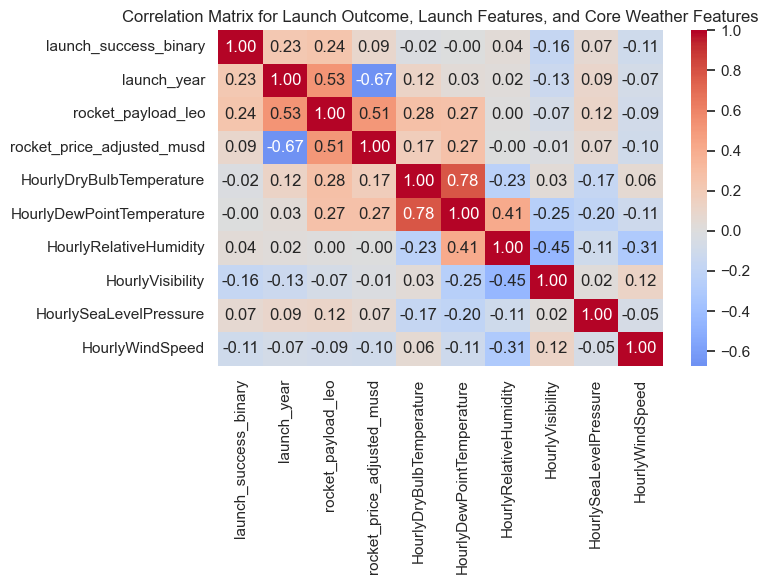

In [42]:
weather_corr_features = [
    "launch_success_binary",
    "launch_year",
    "rocket_payload_leo",
    "rocket_price_adjusted_musd",
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
]
weather_corr_matrix = matched_launch_weather[weather_corr_features].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(weather_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix for Launch Outcome, Launch Features, and Core Weather Features")
plt.tight_layout()
plt.show()


## Write Derived Files

These CSV outputs are ready to reuse in the next stage of the project.


In [43]:
us_site_summary_export = (
    us_launches.groupby("facility_group")
    .agg(
        launches=("Launch Id", "count"),
        raw_location_strings=("Location", "nunique"),
        first_launch=("launch_date", "min"),
        last_launch=("launch_date", "max"),
        success_rate=("Launch Status", lambda s: (s == "Success").mean()),
    )
    .reset_index()
    .sort_values("launches", ascending=False)
)

us_site_summary_export.to_csv(OUTPUT_DIR / "us_launch_site_summary.csv", index=False)
raw_location_zip_map.to_csv(OUTPUT_DIR / "us_launch_zip_candidates.csv", index=False)
noaa_pull_plan.to_csv(OUTPUT_DIR / "noaa_pull_plan.csv", index=False)
final_noaa_pull_reference.to_csv(OUTPUT_DIR / "final_noaa_pull_reference.csv", index=False)
weather_merge_coverage.to_csv(OUTPUT_DIR / "weather_merge_coverage.csv", index=False)
weather_feature_availability.to_csv(OUTPUT_DIR / "weather_feature_availability.csv", index=False)
weather_by_outcome_summary.to_csv(OUTPUT_DIR / "weather_by_outcome_summary.csv", index=False)
launch_feature_availability.to_csv(OUTPUT_DIR / "launch_feature_availability.csv", index=False)
launch_feature_outcome_summary.to_csv(OUTPUT_DIR / "launch_feature_outcome_summary.csv", index=False)
rocket_org_outcomes.to_csv(OUTPUT_DIR / "rocket_org_outcomes.csv", index=False)
rocket_family_outcomes.to_csv(OUTPUT_DIR / "rocket_family_outcomes.csv", index=False)
config_status_outcomes.to_csv(OUTPUT_DIR / "config_status_outcomes.csv", index=False)
payload_success_profile.to_csv(OUTPUT_DIR / "payload_success_profile.csv", index=False)
us_launch_weather.to_csv(OUTPUT_DIR / "us_launch_weather_merged.csv", index=False)

pd.DataFrame(
    {
        "file": [
            str(OUTPUT_DIR / "us_launch_site_summary.csv"),
            str(OUTPUT_DIR / "us_launch_zip_candidates.csv"),
            str(OUTPUT_DIR / "noaa_pull_plan.csv"),
            str(OUTPUT_DIR / "final_noaa_pull_reference.csv"),
            str(OUTPUT_DIR / "weather_merge_coverage.csv"),
            str(OUTPUT_DIR / "weather_feature_availability.csv"),
            str(OUTPUT_DIR / "weather_by_outcome_summary.csv"),
            str(OUTPUT_DIR / "launch_feature_availability.csv"),
            str(OUTPUT_DIR / "launch_feature_outcome_summary.csv"),
            str(OUTPUT_DIR / "rocket_org_outcomes.csv"),
            str(OUTPUT_DIR / "rocket_family_outcomes.csv"),
            str(OUTPUT_DIR / "config_status_outcomes.csv"),
            str(OUTPUT_DIR / "payload_success_profile.csv"),
            str(OUTPUT_DIR / "us_launch_weather_merged.csv"),
        ]
    }
)


,file
0,data\derived\us_launch_site_summary.csv
1,data\derived\us_launch_zip_candidates.csv
2,data\derived\noaa_pull_plan.csv
3,data\derived\final_noaa_pull_reference.csv
4,data\derived\weather_merge_coverage.csv
5,data\derived\weather_feature_availability.csv
6,data\derived\weather_by_outcome_summary.csv
7,data\derived\launch_feature_availability.csv
8,data\derived\launch_feature_outcome_summary.csv
9,data\derived\rocket_org_outcomes.csv


## Bottom Line

The U.S. portion of the launch dataset spans **1957-12-06 to 2021-12-21** and is
dominated by two facilities:
- Cape Canaveral / Kennedy
- Vandenberg

NOAA extraction can now use the final facility-level reference table written above instead
of the raw pad-level location strings. With your manual ZIP entries added, every U.S.
facility in scope now has a resolved ZIP/date pull specification. The notebook also
produces an event-level launch-weather table that can be used directly for downstream
modeling.
